In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings('ignore')
import os

import random
from plotnine  import * 

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
import forestci as fci

import dice_ml
from quantile_forest import RandomForestQuantileRegressor
import shap



%matplotlib inline


In [4]:
# Read in input file

path = '/home/mgabr001/BrainGenix/BrainEmulationChallenge/src/models/autoassociative/NetmorphParOptim'
os.chdir(path)

df = pd.read_excel(open('ParameterSpace_700_samples-labeled.xlsx','rb'))    

print(df.shape)
print(df.columns)



(700, 9)
Index(['days', 'pyramidal', 'interneuron', 'minneuronseparation',
       'shape.radius', 'shape.thickness', 'dm.weight', 'usable_conns1',
       'usable_conns2'],
      dtype='str')


In [5]:
# Select Only Needed Columns

columnsA = ['days', 'pyramidal', 'interneuron', 'minneuronseparation',
       'shape.radius', 'shape.thickness', 'dm.weight', 'usable_conns1',
       'usable_conns2']


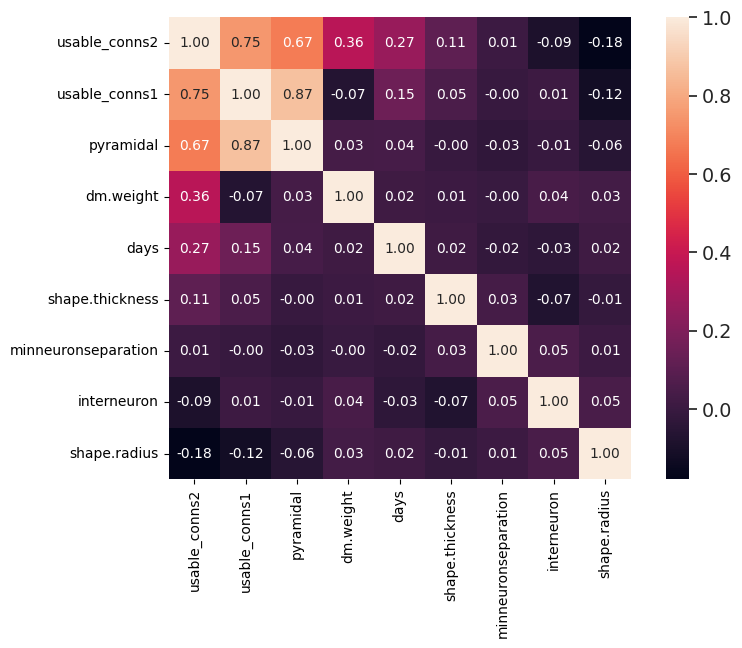

In [6]:

# correlation matrix
f, ax = plt.subplots(figsize=(9, 6))
k = 10 #number of variables for heatmap
corrmat = df[columnsA].corr()
cols = corrmat.nlargest(k, 'usable_conns2')['usable_conns2'].index
cm = np.corrcoef(df[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()
f.savefig('Correlation_Matrix.png')

## Create Training and Test datasets: split 80% and 20%

In [7]:
cols = ['days', 'pyramidal', 'interneuron', 'minneuronseparation',
       'shape.radius', 'shape.thickness', 'dm.weight']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(df[cols],df['usable_conns2'], test_size=0.2, random_state=27)
X_train.shape

(560, 7)

In [9]:
print(X_train.head())
print(y_train.head()) 

     days  pyramidal  interneuron  minneuronseparation  shape.radius  \
623    22         48           72                   11           160   
372    20         48           40                   14           190   
246    22         64           16                   13           160   
38     21         88          128                   14           200   
562    24        104           32                   15           180   

     shape.thickness  dm.weight  
623               30        0.5  
372               20        0.9  
246               50        0.8  
38                40        0.6  
562               40        0.8  
623     193
372     208
246     521
38      311
562    1218
Name: usable_conns2, dtype: int64


In [87]:
clf = RandomForestRegressor(n_estimators=1000, bootstrap = True, oob_score = True, random_state = 27)
model = clf.fit(X_train, y_train)

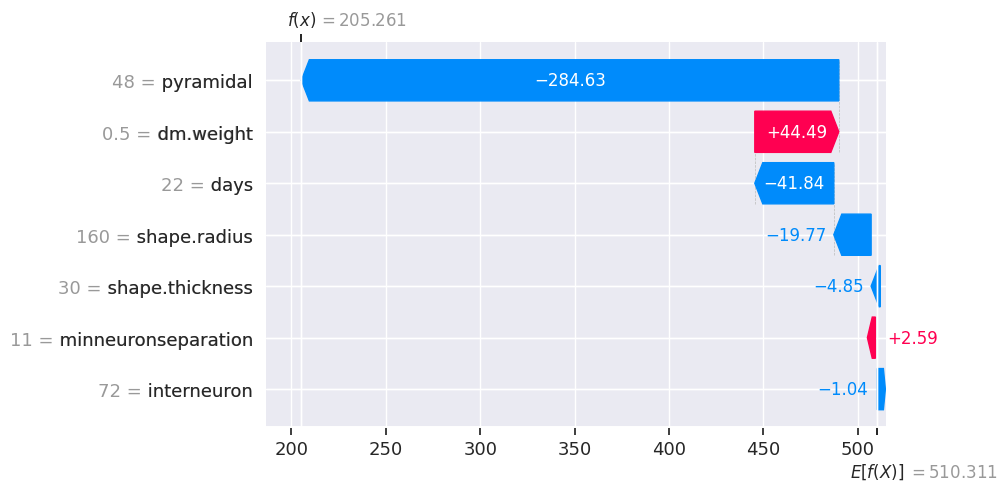

In [11]:
# explain the model's predictions using SHAP
# (same syntax works for LightGBM, CatBoost, scikit-learn, transformers, Spark, etc.)

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)

# visualize the first prediction's explanation
shap.plots.waterfall(shap_values[0])

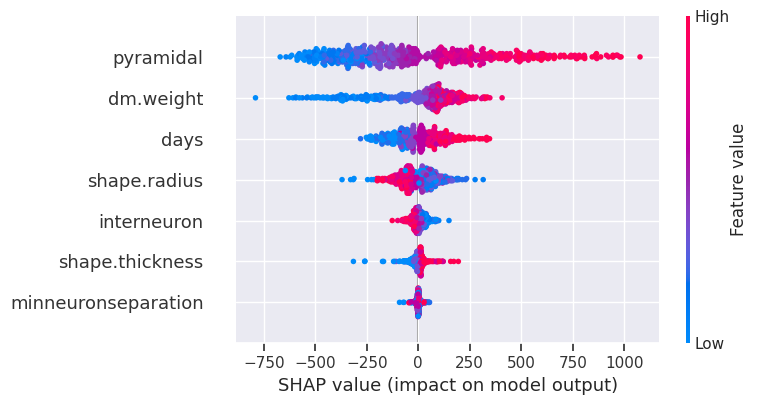

In [20]:
shap.summary_plot(shap_values, X_train)

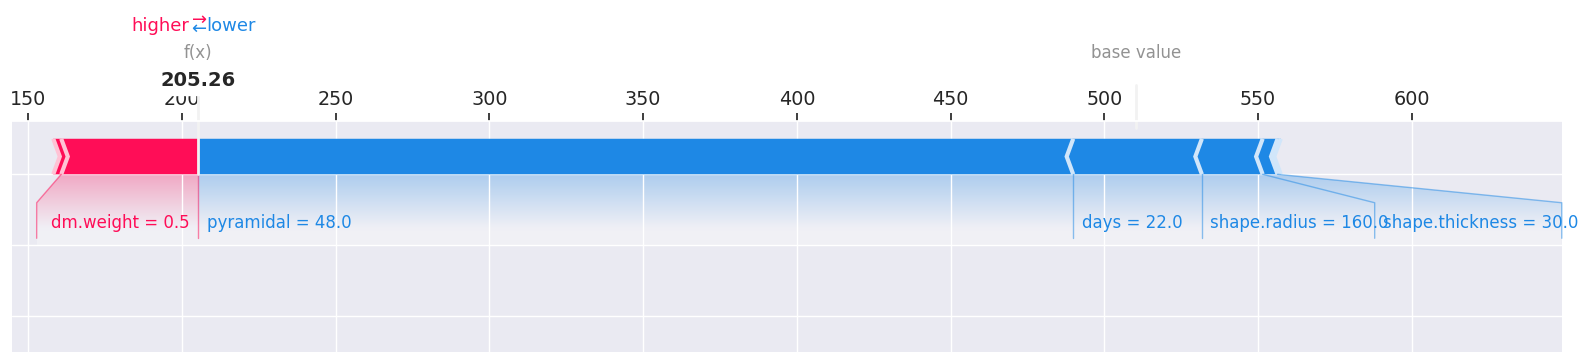

In [67]:
# visualize the first prediction's explanation with a force plot
shap.plots.force(shap_values[0], matplotlib=True)

In [28]:
shap_values.shape

(560, 7)

In [97]:
# shap_values[0]

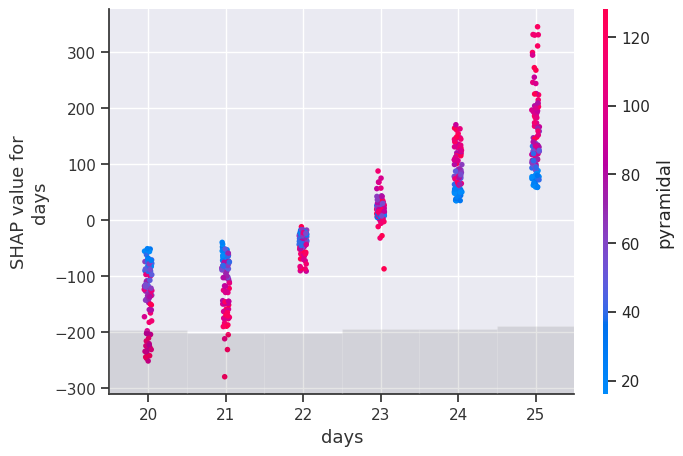

In [36]:
# create a dependence scatter plot to show the effect of a single feature across the whole dataset
shap.plots.scatter(shap_values[:, "days"], color=shap_values)

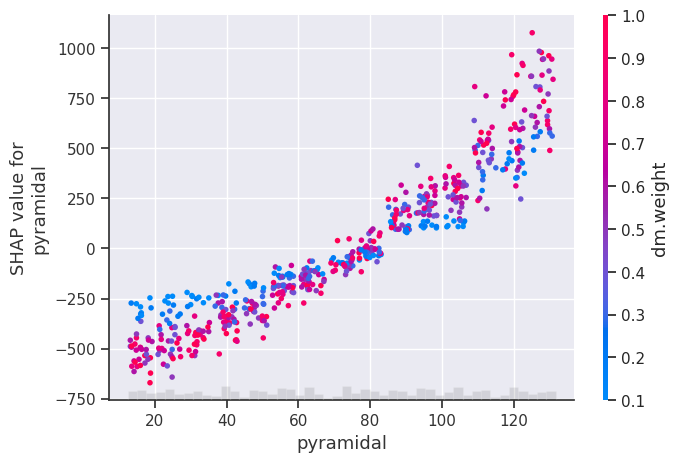

In [37]:
# create a dependence scatter plot to show the effect of a single feature across the whole dataset
shap.plots.scatter(shap_values[:, "pyramidal"], color=shap_values)

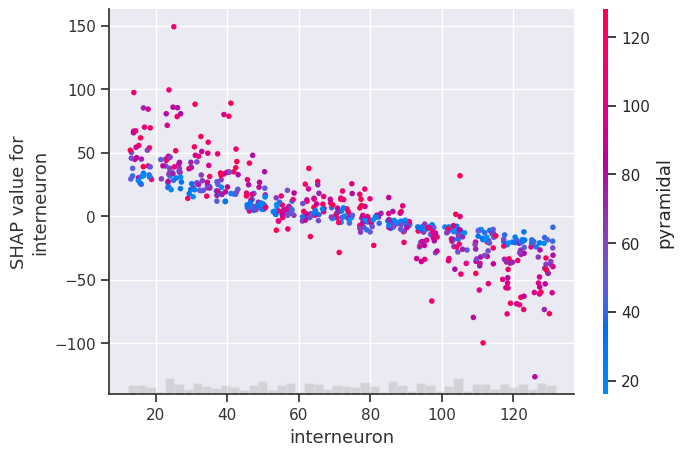

In [79]:
# create a dependence scatter plot to show the effect of a single feature across the whole dataset
shap.plots.scatter(shap_values[:, "interneuron"], color=shap_values)


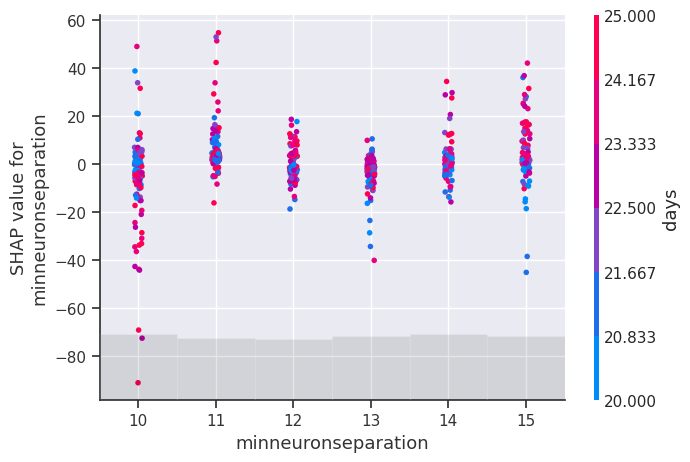

In [80]:
shap.plots.scatter(shap_values[:, "minneuronseparation"], color=shap_values)

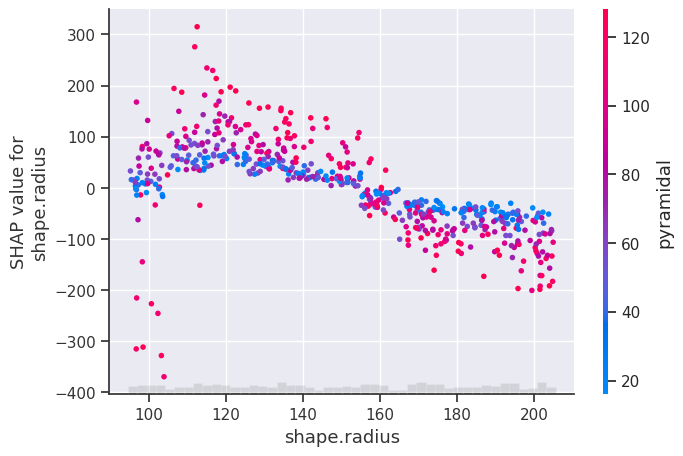

In [81]:
shap.plots.scatter(shap_values[:, "shape.radius"], color=shap_values)

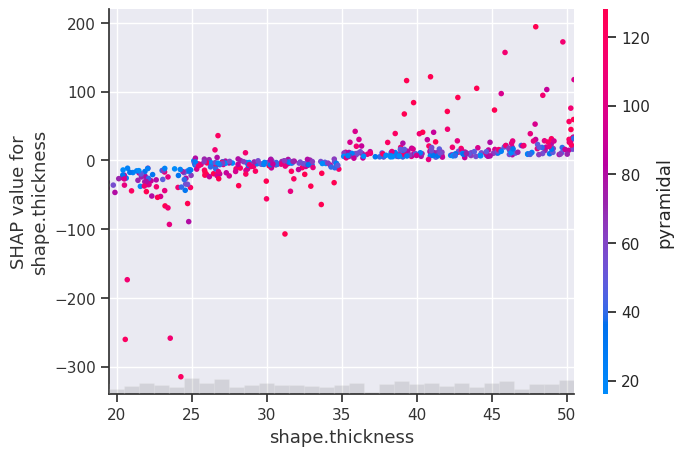

In [82]:
shap.plots.scatter(shap_values[:, "shape.thickness"], color=shap_values)

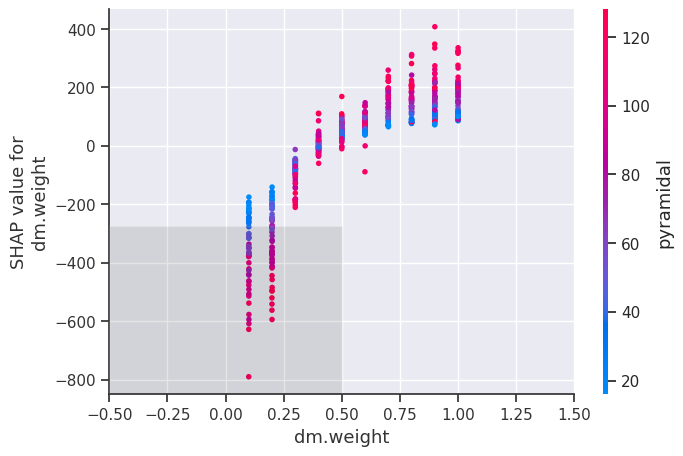

In [83]:
shap.plots.scatter(shap_values[:, "dm.weight"], color=shap_values)

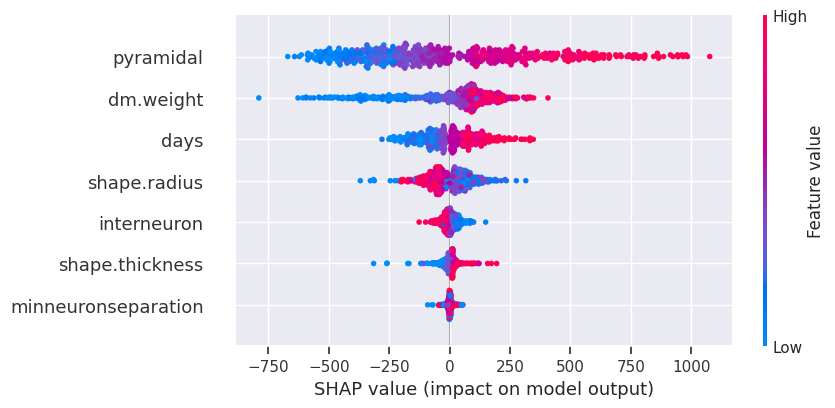

In [39]:
# summarize the effects of all the features
shap.plots.beeswarm(shap_values)

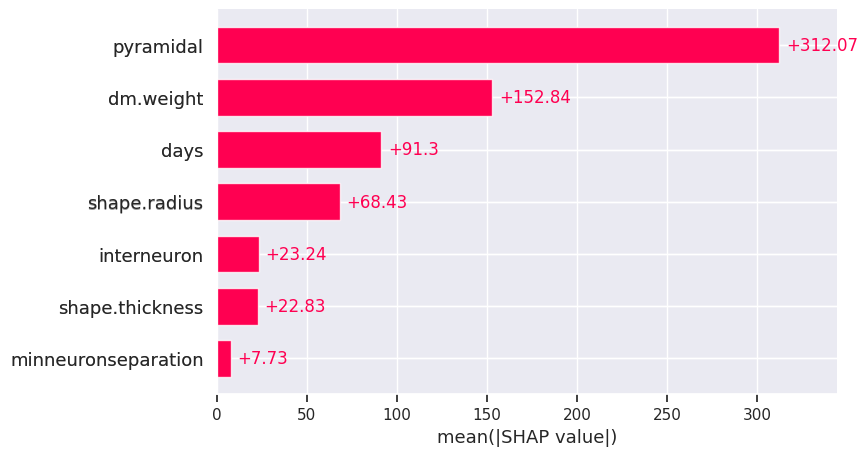

In [40]:
shap.plots.bar(shap_values)

In [ ]:
qrf = RandomForestQuantileRegressor(n_estimators=1000, bootstrap = True, oob_score = True, random_state = 27, default_quantiles=0.025)
qrf.fit(X_train, y_train)

,n_estimators,1000
,default_quantiles,0.025
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,max_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0


In [118]:

# 2. Create a "Conservative" Model Wrapper
# This wrapper tells the optimizer to look at the BOTTOM of the 95% interval
class ConservativeModel:
    def __init__(self, model, threshold):
        self.model = model
        self.threshold = threshold
    
    def predict(self, instances):
        # We predict the 0.025 quantile (Lower Bound)
        # If the Lower Bound > threshold, we are 97.5% sure the real value is too.
        return self.model.predict(instances, quantiles=0.025)

In [119]:

# Wrap the model for DiCE
conservative_wrapper = ConservativeModel(qrf, threshold=500)
m = dice_ml.Model(model=conservative_wrapper, backend="sklearn", model_type='regressor')

# 3. Setup DiCE with your specific NETMORPH features
d = dice_ml.Data(dataframe=pd.concat([X_train[cols], y_train], axis=1), 
                 continuous_features=cols, 
                 outcome_name='usable_conns2')

exp = dice_ml.Dice(d, m, method="random")


In [120]:

# 4. Generate Counterfactuals
# We search for parameters where the LOWER BOUND of the model is > threshold
query_instance = X_test[cols].iloc[0:1]
dice_exp = exp.generate_counterfactuals(
    query_instance, 
    total_CFs=7, 
    desired_range=[500.0, 3000.0], # Target range for the lower bound
    permitted_range={'days': [20,25], 
                     'pyramidal': [16, 128], 
                     'interneuron': [16, 128], 
                     'minneuronseparation': [10, 15], 
                     'shape.radius': [100, 200], 
                     'shape.thickness': [20.0, 50.0], 
                     'dm.weight': [0.1, 1.0]}
)

dice_exp.visualize_as_dataframe(show_only_changes=True)


100%|██████████| 1/1 [00:02<00:00,  2.78s/it]

Query instance (original outcome : 624.0)


,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,usable_conns2
0,23,128,104,12,140,30,0.6,624.0



Diverse Counterfactual set (new outcome: [500.0, 3000.0])


,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,usable_conns2
0,-,-,-,-,-,40.0,0.5,746.0
1,-,-,79.0,-,-,24.0,-,-
2,-,-,-,-,137.0,-,-,-
3,-,109.0,19.0,-,-,-,-,747.9500122070312
4,-,-,20.0,13.0,-,-,-,909.0
5,-,-,19.0,14.0,-,-,-,928.0
6,-,-,40.0,-,-,-,-,909.0
